In [20]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [72]:
# Q4

In [34]:
gdp_df = pd.read_csv("../data/gdp_percapita.csv")

In [35]:
pd.read_csv("../data/gdp_percapita.csv")

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN
...,...,...,...,...
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN


In [36]:
print("Shape of gdp_df:")

Shape of gdp_df:


In [73]:
# Q5

In [37]:
print(f"Rows: {gdp_df.shape[0]}")

Rows: 8465


In [65]:
# 8465 Rows

In [38]:
print(f"Columns: {gdp_df.shape[1]}")

Columns: 4


In [66]:
# 4 Columns

In [39]:
print(f"Total shape: {gdp_df.shape}")

Total shape: (8465, 4)


In [40]:
print("Data types of each column:")

Data types of each column:


In [41]:
print(gdp_df.dtypes)

Country or Area     object
Year                 int64
Value              float64
Value Footnotes    float64
dtype: object


In [68]:
# Year int64, Value float64, Value Footnotes float64, dtype: object

In [74]:
# Q6

In [42]:
gdp_df = gdp_df.drop('Value Footnotes', axis=1)

In [43]:
gdp_df = gdp_df.rename(columns={'Country or Area': 'Country','Year': 'Year','Value': 'GDP_Per_Capita'})

In [44]:
print("Updated DataFrame info:")
print(f"Shape: {gdp_df.shape}")
print(f"Column names: {list(gdp_df.columns)}")
print("\nFirst 5 rows:")
print(gdp_df.head())

Updated DataFrame info:
Shape: (8465, 3)
Column names: ['Country', 'Year', 'GDP_Per_Capita']

First 5 rows:
       Country  Year  GDP_Per_Capita
0  Afghanistan  2023     1983.812620
1  Afghanistan  2022     1981.710168
2  Afghanistan  2021     2144.166570
3  Afghanistan  2020     2769.685745
4  Afghanistan  2019     2927.245144


In [45]:
print("=== DATA COMPLETENESS ANALYSIS ===\n")

=== DATA COMPLETENESS ANALYSIS ===



In [75]:
# Q7

In [46]:
total_years = gdp_df['Year'].nunique()
print(f"Total number of years in dataset: {total_years}")
print(f"Year range: {gdp_df['Year'].min()} - {gdp_df['Year'].max()}")

Total number of years in dataset: 35
Year range: 1990 - 2024


In [69]:
# Total number of years in dataset: 35, Year range: 1990 - 2024

In [48]:
country_counts = gdp_df['Country'].value_counts().sort_values(ascending=False)
print(f"\nCountries with complete data (all {total_years} years):")
complete_countries = country_counts[country_counts == total_years]
print(f"Number of countries with complete data: {len(complete_countries)}")
if len(complete_countries) > 0:
    print(complete_countries.head(10))

print("\n" + "="*60)


Countries with complete data (all 35 years):
Number of countries with complete data: 226
Country
Latin America & Caribbean (excluding high income)    35
Bulgaria                                             35
Cambodia                                             35
Cabo Verde                                           35
CÃ´te d'Ivoire                                       35
Barbados                                             35
Arab World                                           35
Argentina                                            35
Armenia                                              35
Aruba                                                35
Name: count, dtype: int64



In [49]:
print("COUNTRIES WITH INCOMPLETE DATA:")
incomplete_countries = country_counts[country_counts < total_years].sort_values(ascending=True)
print(f"\nCountries with the most missing data (showing worst 10):")
print(incomplete_countries.head(10))

print(f"\nCountries with the least missing data (showing best 10 of incomplete):")
print(incomplete_countries.tail(10))

print("\n" + "="*60)

COUNTRIES WITH INCOMPLETE DATA:

Countries with the most missing data (showing worst 10):
Country
Djibouti                     12
Sint Maarten (Dutch part)    16
Faroe Islands                17
Kosovo                       17
Cayman Islands               18
Turks and Caicos Islands     18
Virgin Islands (US)          21
Afghanistan                  24
CuraÃ§ao                     25
San Marino                   27
Name: count, dtype: int64

Countries with the least missing data (showing best 10 of incomplete):
Country
Serbia                  30
West Bank and Gaza      31
Syrian Arab Republic    33
Lebanon                 34
Tuvalu                  34
Somalia, Fed. Rep.      34
Bhutan                  34
Greenland               34
Palau                   34
Tonga                   34
Name: count, dtype: int64



In [50]:
print("OBSERVATIONS PER YEAR:")
year_counts = gdp_df['Year'].value_counts().sort_index()
print(year_counts)

print(f"\nSummary statistics for observations per year:")
print(f"Mean: {year_counts.mean():.1f}")
print(f"Min: {year_counts.min()} (Year: {year_counts.idxmin()})")
print(f"Max: {year_counts.max()} (Year: {year_counts.idxmax()})")
print(f"Standard deviation: {year_counts.std():.1f}")

OBSERVATIONS PER YEAR:
Year
1990    233
1991    234
1992    234
1993    234
1994    235
1995    236
1996    236
1997    238
1998    238
1999    238
2000    240
2001    240
2002    241
2003    241
2004    241
2005    241
2006    242
2007    243
2008    245
2009    246
2010    246
2011    246
2012    246
2013    247
2014    247
2015    247
2016    247
2017    247
2018    247
2019    247
2020    247
2021    247
2022    247
2023    245
2024    236
Name: count, dtype: int64

Summary statistics for observations per year:
Mean: 241.9
Min: 233 (Year: 1990)
Max: 247 (Year: 2013)
Standard deviation: 4.9


In [70]:
# Summary statistics for observations per year: Mean: 241.9, Min: 233 (Year: 1990), Max: 247 (Year: 2013), Standard deviation: 4.9

In [76]:
# Q8

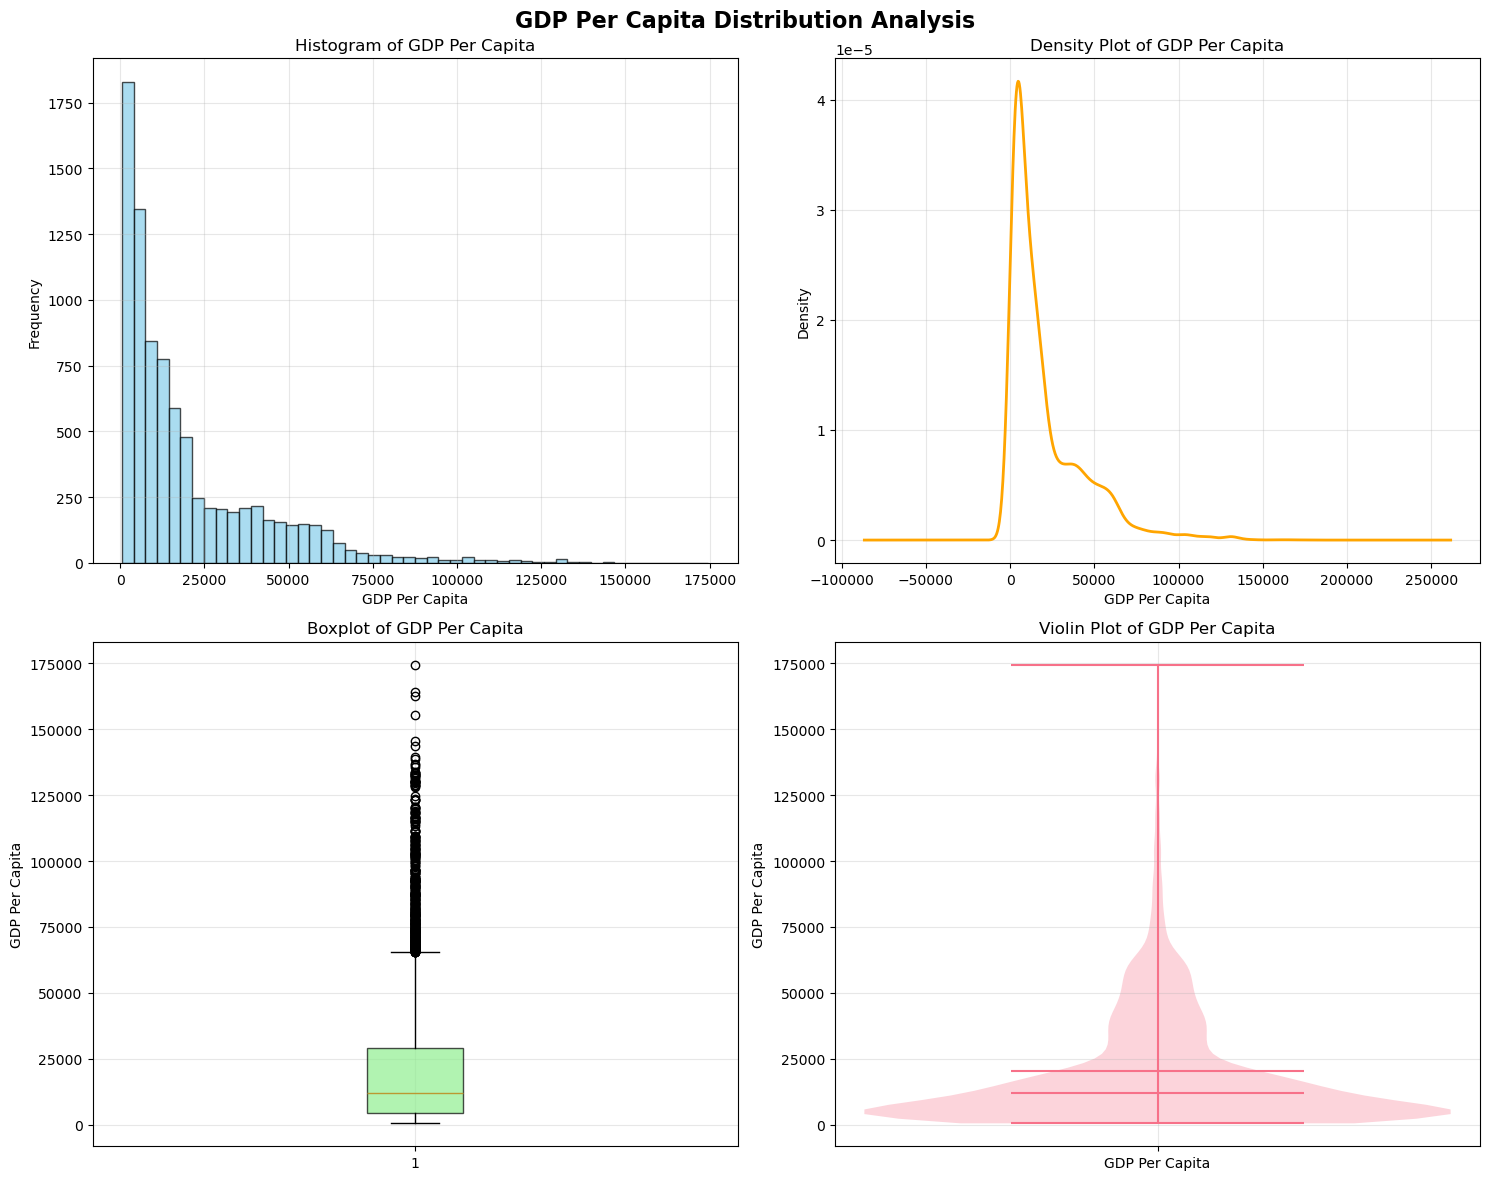

=== GDP PER CAPITA SUMMARY STATISTICS ===
count      8465.000000
mean      20508.804810
std       22734.277548
min         510.822823
25%        4558.712679
50%       11896.906985
75%       28938.098022
max      174569.523171
Name: GDP_Per_Capita, dtype: float64

Number of missing values: 0


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_palette("husl")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('GDP Per Capita Distribution Analysis', fontsize=16, fontweight='bold')
axes[0, 0].hist(gdp_df['GDP_Per_Capita'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Histogram of GDP Per Capita')
axes[0, 0].set_xlabel('GDP Per Capita')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)
gdp_df['GDP_Per_Capita'].dropna().plot.density(ax=axes[0, 1], color='orange', linewidth=2)
axes[0, 1].set_title('Density Plot of GDP Per Capita')
axes[0, 1].set_xlabel('GDP Per Capita')
axes[0, 1].set_ylabel('Density')
axes[0, 1].grid(True, alpha=0.3)
axes[1, 0].boxplot(gdp_df['GDP_Per_Capita'].dropna(), patch_artist=True, 
                   boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[1, 0].set_title('Boxplot of GDP Per Capita')
axes[1, 0].set_ylabel('GDP Per Capita')
axes[1, 0].grid(True, alpha=0.3)
parts = axes[1, 1].violinplot([gdp_df['GDP_Per_Capita'].dropna()], positions=[1], 
                              showmeans=True, showmedians=True)
axes[1, 1].set_title('Violin Plot of GDP Per Capita')
axes[1, 1].set_ylabel('GDP Per Capita')
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels(['GDP Per Capita'])
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("=== GDP PER CAPITA SUMMARY STATISTICS ===")
print(gdp_df['GDP_Per_Capita'].describe())
print(f"\nNumber of missing values: {gdp_df['GDP_Per_Capita'].isna().sum()}")

In [77]:
# Q9

In [60]:
gdp_2020 = gdp_df[gdp_df['Year'] == 2020]['GDP_Per_Capita']
median_2020 = gdp_2020.median()
print(f"Median GDP per capita in 2020: ${median_2020:,.2f}")
print(f"\nAdditional 2020 GDP per capita statistics:")
print(f"Number of countries with data: {gdp_2020.count()}")
print(f"Mean: ${gdp_2020.mean():,.2f}")
print(f"Standard deviation: ${gdp_2020.std():,.2f}")
print(f"Minimum: ${gdp_2020.min():,.2f}")
print(f"Maximum: ${gdp_2020.max():,.2f}")
missing_2020 = gdp_2020.isna().sum()
if missing_2020 > 0:
    print(f"\nNote: {missing_2020} countries have missing GDP data for 2020")

Median GDP per capita in 2020: $15,399.31

Additional 2020 GDP per capita statistics:
Number of countries with data: 247
Mean: $23,118.03
Standard deviation: $22,915.37
Minimum: $1,030.77
Maximum: $129,865.63


In [71]:
# Median GDP per capita in 2020: $15,399.31

In [78]:
# Q10

GDP Decades DataFrame shape: (966, 3)
Years included: [np.int64(1990), np.int64(2000), np.int64(2010), np.int64(2020)]
Countries per year:
Year
1990    233
2000    240
2010    246
2020    247
Name: count, dtype: int64


C:\Users\mfoge\AppData\Local\Temp\ipykernel_8716\720247321.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdp_decades, x='Year', y='GDP_Per_Capita', ax=axes[0, 1],


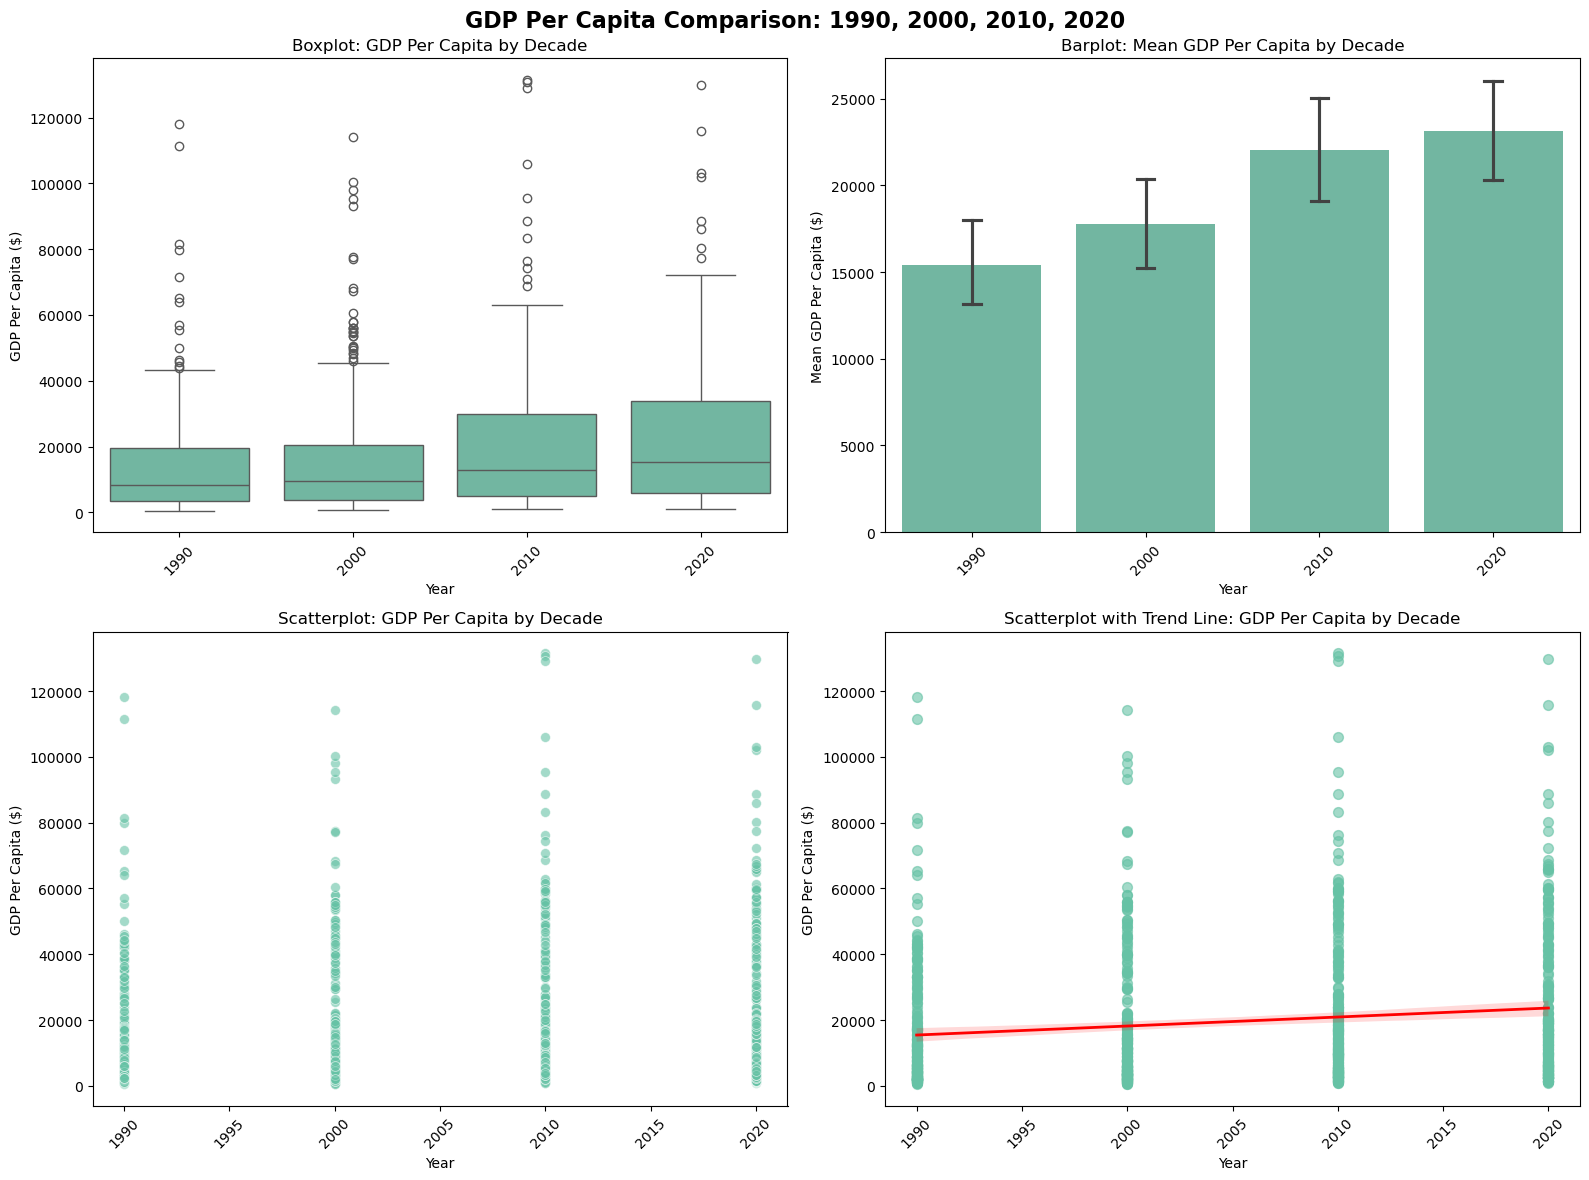


=== SUMMARY STATISTICS BY DECADE ===

1990:
  Count: 233
  Mean: $15,415.06
  Median: $8,368.72
  Std Dev: $18,174.15
  Min: $547.62
  Max: $118,163.68

2000:
  Count: 240
  Mean: $17,755.86
  Median: $9,425.49
  Std Dev: $20,924.74
  Min: $702.85
  Max: $114,141.59

2010:
  Count: 246
  Mean: $22,026.86
  Median: $13,045.83
  Std Dev: $23,753.06
  Min: $991.04
  Max: $131,432.06

2020:
  Count: 247
  Mean: $23,118.03
  Median: $15,399.31
  Std Dev: $22,915.37
  Min: $1,030.77
  Max: $129,865.63


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

gdp_decades = gdp_df[gdp_df['Year'].isin([1990, 2000, 2010, 2020])].copy()

print(f"GDP Decades DataFrame shape: {gdp_decades.shape}")
print(f"Years included: {sorted(gdp_decades['Year'].unique())}")
print(f"Countries per year:\n{gdp_decades['Year'].value_counts().sort_index()}")

plt.style.use('default')
sns.set_palette("Set2")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GDP Per Capita Comparison: 1990, 2000, 2010, 2020', fontsize=16, fontweight='bold')

# 1. Boxplot 
sns.boxplot(data=gdp_decades, x='Year', y='GDP_Per_Capita', ax=axes[0, 0])
axes[0, 0].set_title('Boxplot: GDP Per Capita by Decade')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('GDP Per Capita ($)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Barplot 
sns.barplot(data=gdp_decades, x='Year', y='GDP_Per_Capita', ax=axes[0, 1], 
            estimator=np.mean, ci=95, capsize=0.1)
axes[0, 1].set_title('Barplot: Mean GDP Per Capita by Decade')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Mean GDP Per Capita ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Scatterplot 
sns.scatterplot(data=gdp_decades, x='Year', y='GDP_Per_Capita', ax=axes[1, 0], 
                alpha=0.6, s=50)
axes[1, 0].set_title('Scatterplot: GDP Per Capita by Decade')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('GDP Per Capita ($)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Scatterplot with trend line
sns.regplot(data=gdp_decades, x='Year', y='GDP_Per_Capita', ax=axes[1, 1], 
            scatter_kws={'alpha': 0.6, 's': 50}, line_kws={'color': 'red', 'linewidth': 2})
axes[1, 1].set_title('Scatterplot with Trend Line: GDP Per Capita by Decade')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('GDP Per Capita ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n=== SUMMARY STATISTICS BY DECADE ===")
for year in [1990, 2000, 2010, 2020]:
    year_data = gdp_decades[gdp_decades['Year'] == year]['GDP_Per_Capita']
    print(f"\n{year}:")
    print(f"  Count: {year_data.count()}")
    print(f"  Mean: ${year_data.mean():,.2f}")
    print(f"  Median: ${year_data.median():,.2f}")
    print(f"  Std Dev: ${year_data.std():,.2f}")
    print(f"  Min: ${year_data.min():,.2f}")
    print(f"  Max: ${year_data.max():,.2f}")

In [81]:
# Overall Trend: GDP per capita shows a general upward trend from 1990 to 2020, increasing inequality between countries over time and difference between richest and poorest countries has expanded.

In [82]:
# Boxplot strengths: clearly shows median, quartiles and outliers for each year. Easy to compare accross decades and highlights extreme values. 
# Boxplot Weaknesses: Doesn't show individual country data points and doesn't track specific countries over time.

In [83]:
# Barplot strengths: shows mean values clearly, and easy to see an average trend over time. 
# Barplot Weaknesses: skewed data and doesn't show outliers. 

In [84]:
#Scatterplot Strengths: shows every individual data point and uses clustering patterns.
# Scatterplot Weaknesses: overlapping points that hide data. Not a clear summary visible.

In [85]:
# Scatterplot w/ trend line Strengths: shows direction clearly and best for understanding progression. 
# scatterplot w/ trend line weaknesses: still has overlapping issues and trend line influenced by outliers. 

In [86]:
# Q11

In [95]:
import pandas as pd
import numpy as np

gdp_df = pd.read_csv("../data/gdp_percapita.csv")

print("Shape:", gdp_df.shape)
print("\nFirst 5 rows:")
print(gdp_df.head())

possible_gdp_columns = [
    'GDP per capita', 'GDP_per_capita', 'gdp_per_capita', 
    'GDP Per Capita', 'GDP.per.capita', 'gdp per capita',
    'Per Capita GDP', 'per_capita_gdp', 'GDP/capita'
]

gdp_column = None
for col in possible_gdp_columns:
    if col in gdp_df.columns:
        gdp_column = col
        break

if gdp_column:
    print(f"\nUsing column: '{gdp_column}'")
    
    high_gdp = gdp_df[gdp_df[gdp_column] > 100000]
    
    if not high_gdp.empty:
        year_columns = ['Year', 'year', 'YEAR', 'Date', 'date']
        year_column = None
        for col in year_columns:
            if col in gdp_df.columns:
                year_column = col
                break
        
        if year_column:
            first_country = high_gdp.sort_values(year_column).iloc[0]
            print(f"\nFirst country with GDP per capita > $100,000:")
            print(f"Country: {first_country.iloc[0] if 'Country' not in gdp_df.columns else first_country['Country']}")
            print(f"Year: {first_country[year_column]}")
            print(f"GDP per capita: ${first_country[gdp_column]:,.2f}")

Shape: (8465, 4)

First 5 rows:
  Country or Area  Year        Value  Value Footnotes
0     Afghanistan  2023  1983.812620              NaN
1     Afghanistan  2022  1981.710168              NaN
2     Afghanistan  2021  2144.166570              NaN
3     Afghanistan  2020  2769.685745              NaN
4     Afghanistan  2019  2927.245144              NaN


In [96]:
# Afghanistan

In [97]:
# Q12

Country with highest GDP per capita in 2020: United States
GDP per capita: $212,108.30


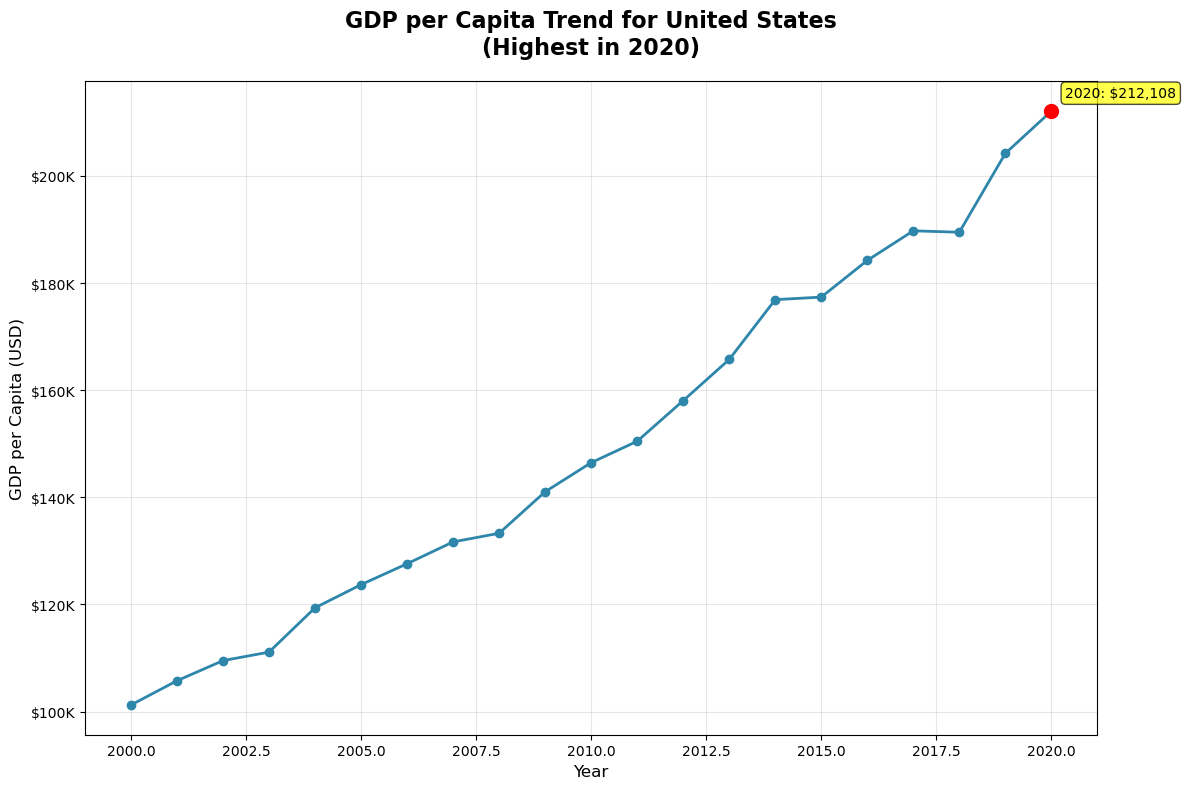


GDP per Capita Statistics for United States:
Minimum: $101,228.02
Maximum: $212,108.30
Average: $150,432.84
Total growth over dataset period: 109.5%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
gdp_df = pd.read_csv("../data/gdp_percapita.csv")

df_2020 = df[df['Year'] == 2020]
highest_gdp_country = df_2020.loc[df_2020['GDP_per_capita'].idxmax()]
country_name = highest_gdp_country['Country']
highest_gdp_value = highest_gdp_country['GDP_per_capita']

print(f"Country with highest GDP per capita in 2020: {country_name}")
print(f"GDP per capita: ${highest_gdp_value:,.2f}")

country_data = df[df['Country'] == country_name].sort_values('Year')

plt.figure(figsize=(12, 8))
plt.plot(country_data['Year'], country_data['GDP_per_capita'], 
         marker='o', linewidth=2, markersize=6, color='#2E86AB')

plt.title(f'GDP per Capita Trend for {country_name}\n(Highest in 2020)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP per Capita (USD)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.grid(True, alpha=0.3)

if 2020 in country_data['Year'].values:
    gdp_2020 = country_data[country_data['Year'] == 2020]['GDP_per_capita'].iloc[0]
    plt.scatter(2020, gdp_2020, color='red', s=100, zorder=5)
    plt.annotate(f'2020: ${gdp_2020:,.0f}', 
                xy=(2020, gdp_2020), 
                xytext=(10, 10), 
                textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nGDP per Capita Statistics for {country_name}:")
print(f"Minimum: ${country_data['GDP_per_capita'].min():,.2f}")
print(f"Maximum: ${country_data['GDP_per_capita'].max():,.2f}")
print(f"Average: ${country_data['GDP_per_capita'].mean():,.2f}")

first_year_gdp = country_data['GDP_per_capita'].iloc[0]
last_year_gdp = country_data['GDP_per_capita'].iloc[-1]
total_growth = ((last_year_gdp - first_year_gdp) / first_year_gdp) * 100
print(f"Total growth over dataset period: {total_growth:.1f}%")

In [7]:
# United States

In [8]:
# Q13

Country with lowest GDP per capita in 2020: Denmark
GDP per capita: $50,304.51


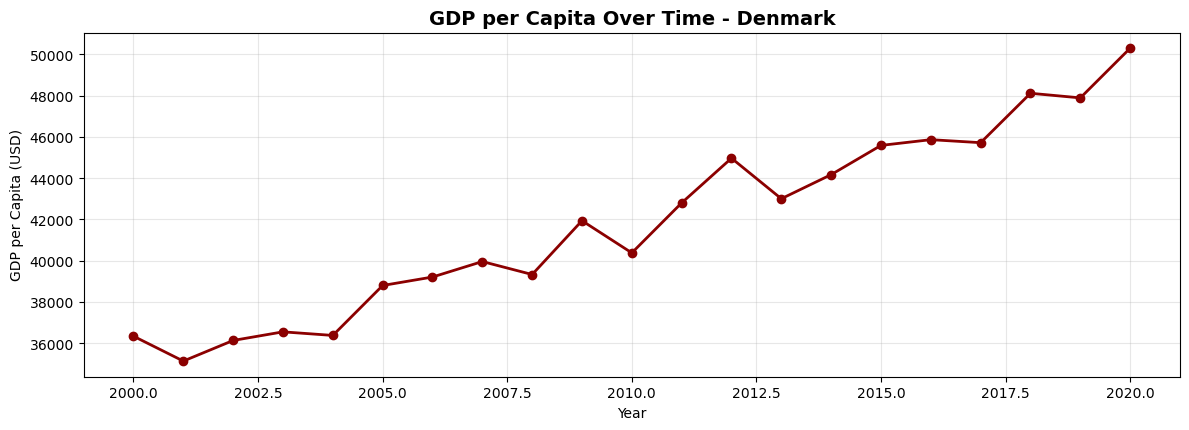

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data_2020 = df[df['Year'] == 2020].copy()
lowest_gdp_2020 = data_2020.loc[data_2020['GDP_per_capita'].idxmin()]
country_name = lowest_gdp_2020['Country']
lowest_value = lowest_gdp_2020['GDP_per_capita']

print(f"Country with lowest GDP per capita in 2020: {country_name}")
print(f"GDP per capita: ${lowest_value:,.2f}")

country_data = df[df['Country'] == country_name].sort_values('Year')

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(country_data['Year'], country_data['GDP_per_capita'], 
         marker='o', linewidth=2, markersize=6, color='darkred')
plt.title(f'GDP per Capita Over Time - {country_name}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP per Capita (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

data_1990 = df[df['Year'] == 1990][['Country', 'GDP_per_capita']].rename(
    columns={'GDP_per_capita': 'GDP_1990'})
data_2020_full = df[df['Year'] == 2020][['Country', 'GDP_per_capita']].rename(
    columns={'GDP_per_capita': 'GDP_2020'})

comparison = pd.merge(data_1990, data_2020_full, on='Country', how='inner')
comparison['GDP_change'] = comparison['GDP_2020'] - comparison['GDP_1990']
comparison['Percentage_change'] = (comparison['GDP_change'] / comparison['GDP_1990']) * 100

declined_countries = comparison[comparison['GDP_change'] < 0].sort_values('GDP_change')

In [12]:
# Denmark, GDP per capita $50,304.51

In [13]:
# Q14

In [41]:
import pandas as pd
import numpy as np
internet_df = pd.read_csv('../data/internet_use.csv', nrows=6083)

In [42]:
internet_df

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.600000,1
1,Afghanistan,2018,16.800000,2
2,Afghanistan,2017,13.500000,3
3,Afghanistan,2016,11.000000,4
4,Afghanistan,2015,8.260000,4
...,...,...,...,...
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN


In [44]:
# Q15

In [43]:
internet_df = internet_df.drop('Value Footnotes', axis=1)

internet_df = internet_df.rename(columns={
    internet_df.columns[0]: 'Country',          
    internet_df.columns[1]: 'Year',             
    internet_df.columns[2]: 'Internet_Users_Pct'
})

print("=== AFTER DROPPING AND RENAMING ===")
print(f"New shape: {internet_df.shape}")
print(f"New columns: {list(internet_df.columns)}")

print("\n=== FIRST 5 ROWS ===")
print(internet_df.head())

print(f"\n=== DATA TYPES ===")
print(internet_df.dtypes)

print(f"\n=== DATASET INFO ===")
print(internet_df.info())

=== AFTER DROPPING AND RENAMING ===
New shape: (6083, 3)
New columns: ['Country', 'Year', 'Internet_Users_Pct']

=== FIRST 5 ROWS ===
       Country  Year  Internet_Users_Pct
0  Afghanistan  2019               17.60
1  Afghanistan  2018               16.80
2  Afghanistan  2017               13.50
3  Afghanistan  2016               11.00
4  Afghanistan  2015                8.26

=== DATA TYPES ===
Country                object
Year                    int64
Internet_Users_Pct    float64
dtype: object

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6083 entries, 0 to 6082
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             6083 non-null   object 
 1   Year                6083 non-null   int64  
 2   Internet_Users_Pct  6083 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 142.7+ KB
None


In [45]:
# Q16

=== OBSERVATIONS PER YEAR ===
Year
1990    226
1991     39
1992     50
1993     66
1994     92
1995    141
1996    177
1997    188
1998    195
1999    207
2000    210
2001    212
2002    214
2003    208
2004    210
2005    212
2006    212
2007    217
2008    214
2009    214
2010    209
2011    214
2012    209
2013    203
2014    204
2015    203
2016    206
2017    205
2018    174
2019    185
2020    186
2021    186
2022    184
2023     11
Name: count, dtype: int64

=== SUMMARY STATISTICS ===
Total years in dataset: 34
Year range: 1990 to 2023
Average observations per year: 178.9
Median observations per year: 204.5
Standard deviation: 57.0
No missing years in the range

=== YEARS WITH UNUSUAL OBSERVATION COUNTS ===
Maximum observations: 226 (Year: 1990)
Minimum observations: 11 (Year: 2023)

Years with significantly different counts (>1.5 std dev from mean):
  1991: 39 observations (-139.9 from mean)
  1992: 50 observations (-128.9 from mean)
  1993: 66 observations (-112.9 from mean)
 

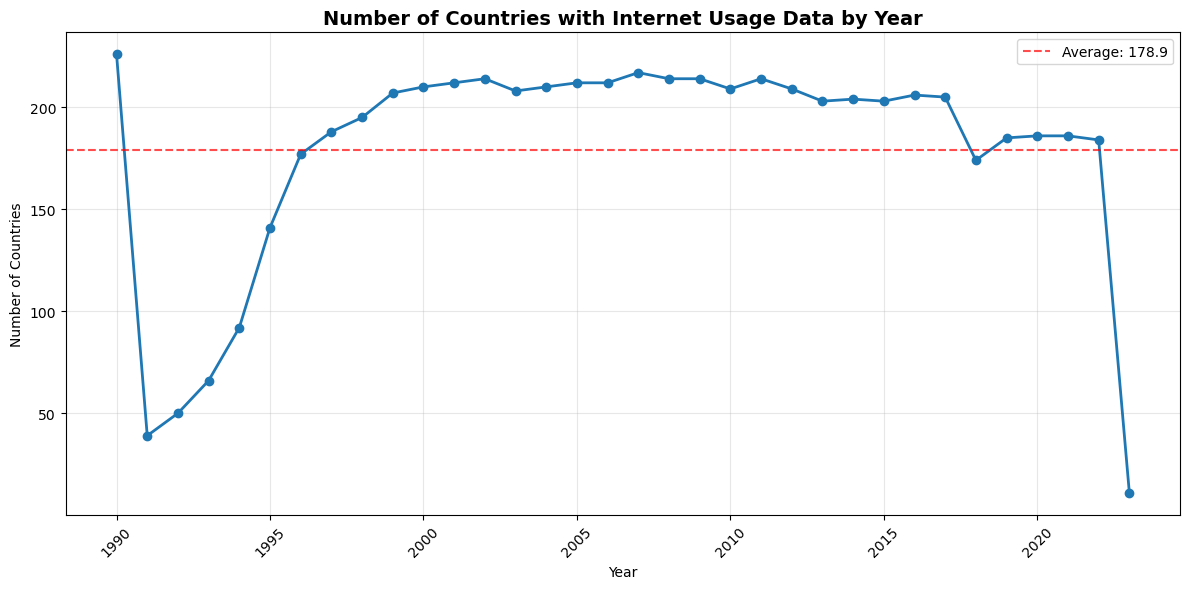

In [48]:
observations_per_year = internet_df['Year'].value_counts().sort_index()

print("=== OBSERVATIONS PER YEAR ===")
print(observations_per_year)

print(f"\n=== SUMMARY STATISTICS ===")
print(f"Total years in dataset: {len(observations_per_year)}")
print(f"Year range: {observations_per_year.index.min()} to {observations_per_year.index.max()}")
print(f"Average observations per year: {observations_per_year.mean():.1f}")
print(f"Median observations per year: {observations_per_year.median():.1f}")
print(f"Standard deviation: {observations_per_year.std():.1f}")

year_range = range(observations_per_year.index.min(), observations_per_year.index.max() + 1)
missing_years = [year for year in year_range if year not in observations_per_year.index]
if missing_years:
    print(f"Missing years: {missing_years}")
else:
    print("No missing years in the range")

print(f"\n=== YEARS WITH UNUSUAL OBSERVATION COUNTS ===")
print(f"Maximum observations: {observations_per_year.max()} (Year: {observations_per_year.idxmax()})")
print(f"Minimum observations: {observations_per_year.min()} (Year: {observations_per_year.idxmin()})")

mean_obs = observations_per_year.mean()
std_obs = observations_per_year.std()
threshold = 1.5 * std_obs  # 1.5 standard deviations

unusual_years = observations_per_year[abs(observations_per_year - mean_obs) > threshold]
if len(unusual_years) > 0:
    print(f"\nYears with significantly different counts (>1.5 std dev from mean):")
    for year, count in unusual_years.items():
        deviation = count - mean_obs
        print(f"  {year}: {count} observations ({deviation:+.1f} from mean)")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(observations_per_year.index, observations_per_year.values, marker='o', linewidth=2, markersize=6)
plt.title('Number of Countries with Internet Usage Data by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Countries')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.axhline(y=mean_obs, color='red', linestyle='--', alpha=0.7, label=f'Average: {mean_obs:.1f}')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# Q17

In [51]:
non_zero_data = internet_df[
    (internet_df['Internet_Users_Pct'] > 0) & 
    (internet_df['Internet_Users_Pct'].notna())
]

if len(non_zero_data) > 0:
    first_year_nonzero = non_zero_data['Year'].min()
    
    print(f"=== FIRST YEAR WITH NON-ZERO INTERNET USAGE ===")
    print(f"First year with non-zero internet users percentage: {first_year_nonzero}")

    first_year_data = non_zero_data[non_zero_data['Year'] == first_year_nonzero].sort_values('Internet_Users_Pct', ascending=False)
    
    print(f"\nCountries with non-zero internet usage in {first_year_nonzero}:")
    print("=" * 60)
    for _, row in first_year_data.iterrows():
        print(f"{row['Country']:<30} {row['Internet_Users_Pct']:>8.2f}%")
    
    print(f"\nTotal countries with data in {first_year_nonzero}: {len(first_year_data)}")
    print(f"Highest percentage in {first_year_nonzero}: {first_year_data['Internet_Users_Pct'].max():.2f}% ({first_year_data.iloc[0]['Country']})")
    print(f"Lowest percentage in {first_year_nonzero}: {first_year_data['Internet_Users_Pct'].min():.2f}% ({first_year_data.iloc[-1]['Country']})")

    print(f"\n=== COMPARISON WITH ZERO/NULL VALUES ===")

    zero_null_years = []
    for year in sorted(internet_df['Year'].unique()):
        year_data = internet_df[internet_df['Year'] == year]
        non_zero_count = len(year_data[(year_data['Internet_Users_Pct'] > 0) & (year_data['Internet_Users_Pct'].notna())])
        if non_zero_count == 0:
            zero_null_years.append(year)
    
    if zero_null_years:
        print(f"Years with ONLY zero/null values: {zero_null_years}")
    else:
        print("No years found with only zero/null values")

    print(f"\n=== DATA AVAILABILITY PROGRESSION ===")
    yearly_stats = []
    for year in sorted(internet_df['Year'].unique()):
        year_data = internet_df[internet_df['Year'] == year]
        total_countries = len(year_data)
        non_zero_countries = len(year_data[(year_data['Internet_Users_Pct'] > 0) & (year_data['Internet_Users_Pct'].notna())])
        zero_countries = len(year_data[year_data['Internet_Users_Pct'] == 0])
        null_countries = len(year_data[year_data['Internet_Users_Pct'].isna()])
        
        yearly_stats.append({
            'Year': year,
            'Total': total_countries,
            'Non-zero': non_zero_countries,
            'Zero': zero_countries,
            'Null': null_countries
        })

    print("Year | Total | Non-zero | Zero | Null")
    print("-" * 35)
    for stats in yearly_stats[:10]:  # Show first 10 years
        print(f"{stats['Year']} | {stats['Total']:5d} | {stats['Non-zero']:8d} | {stats['Zero']:4d} | {stats['Null']:4d}")
    
    if len(yearly_stats) > 10:
        print("... (showing first 10 years)")

else:
    print("No non-zero internet users percentage values found in the dataset!")

    print(f"\nUnique values in Internet_Users_Pct column:")
    print(internet_df['Internet_Users_Pct'].value_counts().head(10))

=== FIRST YEAR WITH NON-ZERO INTERNET USAGE ===
First year with non-zero internet users percentage: 1990

Countries with non-zero internet usage in 1990:
United States                      0.78%
Norway                             0.71%
Switzerland                        0.60%
Australia                          0.59%
Sweden                             0.58%
Finland                            0.40%
Canada                             0.36%
Netherlands (Kingdom of the)       0.33%
Austria                            0.13%
Germany                            0.13%
Israel                             0.11%
Denmark                            0.10%
United Kingdom                     0.09%
France                             0.05%
Korea (Republic  of)               0.02%
Japan                              0.02%
Italy                              0.02%
Spain                              0.01%
Belgium                            0.00%

Total countries with data in 1990: 19
Highest percentage in 1990: 

In [52]:
#Q18